<a href="https://colab.research.google.com/github/Ali13fffff/bank-customer-churn-analysis/blob/main/%20%20%20%20%20churn_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


#Import Libraries

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder as LE
from xgboost import XGBClassifier as XG
from sklearn.model_selection import GridSearchCV, StratifiedKFold,RandomizedSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

Load Data

In [4]:
df=pd.read_csv("Churn_Modelling.csv")
print(df.info())
print(df.head())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1   

Cleaning Data

In [5]:
print(df.isnull().sum())
print(df.duplicated().sum())
df=df.drop(columns=["RowNumber","CustomerId","Surname"])
print(df.info())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non

#Feature Engineering

In [6]:


le = LE()
df['Gender'] = le.fit_transform(df['Gender'])

df = pd.get_dummies(df, columns=['Geography'], drop_first=True, dtype=int)

#Data Splitting

In [7]:
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#Hyperparameter Tuning (RandomizedSearchCV

In [8]:


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {
    "max_depth": [3, 4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200, 300, 400]
}

random_search = RandomizedSearchCV(
    XG(random_state=42, scale_pos_weight=3),
    param_distributions=param_dist,
    n_iter=15,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

print(f"Best params: {random_search.best_params_}")
print(f"Best F1 Score: {random_search.best_score_}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best params: {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05}
Best F1 Score: 0.6190650715735562


#Model Evaluation

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.93      0.86      0.89      1607
           1       0.56      0.74      0.64       393

    accuracy                           0.83      2000
   macro avg       0.74      0.80      0.76      2000
weighted avg       0.86      0.83      0.84      2000

ROC-AUC Score: 0.8723



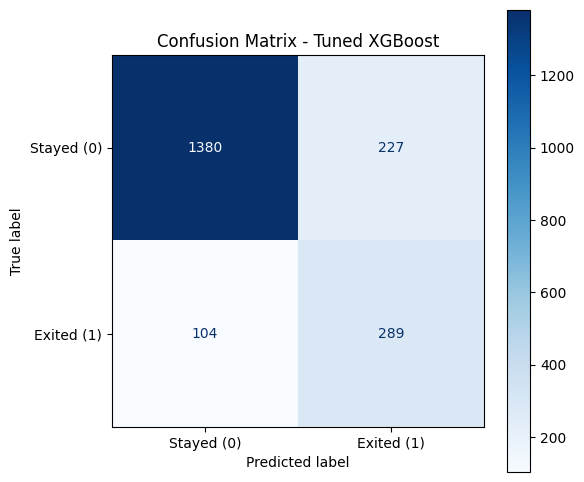

In [9]:



best_model = random_search.best_estimator_


y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]


print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred))


roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}\n")


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed (0)", "Exited (1)"])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("Confusion Matrix - Tuned XGBoost")
plt.grid(False)
plt.show()

#Feature Importance

Feature Importance:
              Feature  Importance
5       NumOfProducts    0.242639
2                 Age    0.213105
7      IsActiveMember    0.176092
9   Geography_Germany    0.123298
1              Gender    0.074262
4             Balance    0.062027
10    Geography_Spain    0.031676
0         CreditScore    0.025232
3              Tenure    0.019850
8     EstimatedSalary    0.017286
6           HasCrCard    0.014534


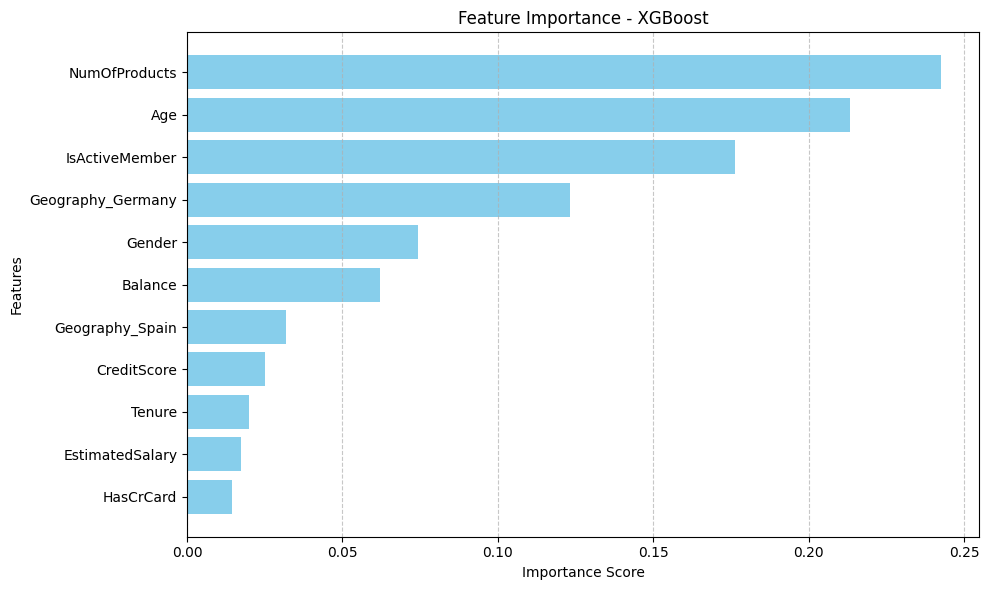

In [10]:


importances = best_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()